# RAGAS Evaluation: Chatbot + KG Answer Quality

**Setup:** 100 open-ended questions across 6 subtypes, evaluated by GPT-4o using the RAGAS framework.

| Metric | Measures | Range |
|--------|----------|-------|
| **Answer Correctness** | Factual F1 (75%) + semantic similarity (25%) vs reference | 0 -- 1 |
| **Answer Relevancy** | Does the answer address the question? | 0 -- 1 |
| **Answer Similarity** | Semantic similarity between answer and reference | 0 -- 1 |
| **Faithfulness** | Are claims grounded in retrieved context? | 0 -- 1 |
| **Context Precision** | Are relevant contexts ranked higher? | 0 -- 1 |
| **Context Recall** | Does context contain all necessary info? | 0 -- 1 |

Ground truths are drawn from `train_77alloys.jsonl`.

In [1]:
import json, warnings
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 130})

ROOT = Path("..")
OUT  = ROOT / "output"

In [2]:
# ── Load data ────────────────────────────────────────────────────────────
with open(OUT / "ragas_scores.json") as f:
    data = json.load(f)

df = pd.DataFrame(data["per_sample"])

METRICS = [
    "answer_correctness", "answer_relevancy", "answer_similarity",
    "faithfulness", "llm_context_precision_with_reference", "context_recall",
]
METRIC_LABELS = [
    "Answer Correctness", "Answer Relevancy", "Answer Similarity",
    "Faithfulness", "Context Precision", "Context Recall",
]
METRIC_MAP = dict(zip(METRICS, METRIC_LABELS))

SUBTYPE_MAP = {
    "descriptive": "Descriptive", "explanatory": "Explanatory",
    "comparative": "Comparative", "recommendation": "Recommendation",
    "multi_property": "Multi-Property", "temperature_trend": "Temp. Trend",
}
SUBTYPE_ORDER = list(SUBTYPE_MAP.values())
df["subtype"] = df["type"].map(SUBTYPE_MAP)

print(f"Loaded {len(df)} samples across {df['subtype'].nunique()} subtypes")
print(f"Counts: {dict(df['subtype'].value_counts().sort_index())}")

Loaded 100 samples across 6 subtypes
Counts: {'Comparative': np.int64(18), 'Descriptive': np.int64(20), 'Explanatory': np.int64(18), 'Multi-Property': np.int64(14), 'Recommendation': np.int64(18), 'Temp. Trend': np.int64(12)}


---
## 1 &ensp; Aggregate Scores

In [3]:
agg = pd.DataFrame({
    "Mean":   [df[m].mean()   for m in METRICS],
    "Median": [df[m].median() for m in METRICS],
    "Std":    [df[m].std()    for m in METRICS],
    "Min":    [df[m].min()    for m in METRICS],
    "Max":    [df[m].max()    for m in METRICS],
}, index=METRIC_LABELS)
agg.index.name = "Metric"

(agg.style
    .format("{:.3f}")
    .background_gradient(cmap="RdYlGn", subset=["Mean"], vmin=0.3, vmax=1.0)
    .set_caption("Table 1 — Aggregate RAGAS scores (n = 100)"))

,Mean,Median,Std,Min,Max
Metric,,,,,
Answer Correctness,0.524,0.497,0.236,0.212,0.946
Answer Relevancy,0.946,0.979,0.141,0.000,1.000
Answer Similarity,0.924,0.930,0.026,0.848,0.963
Faithfulness,0.741,0.800,0.276,0.000,1.000
Context Precision,0.653,1.000,0.473,0.000,1.000
Context Recall,0.484,0.625,0.340,0.000,1.000


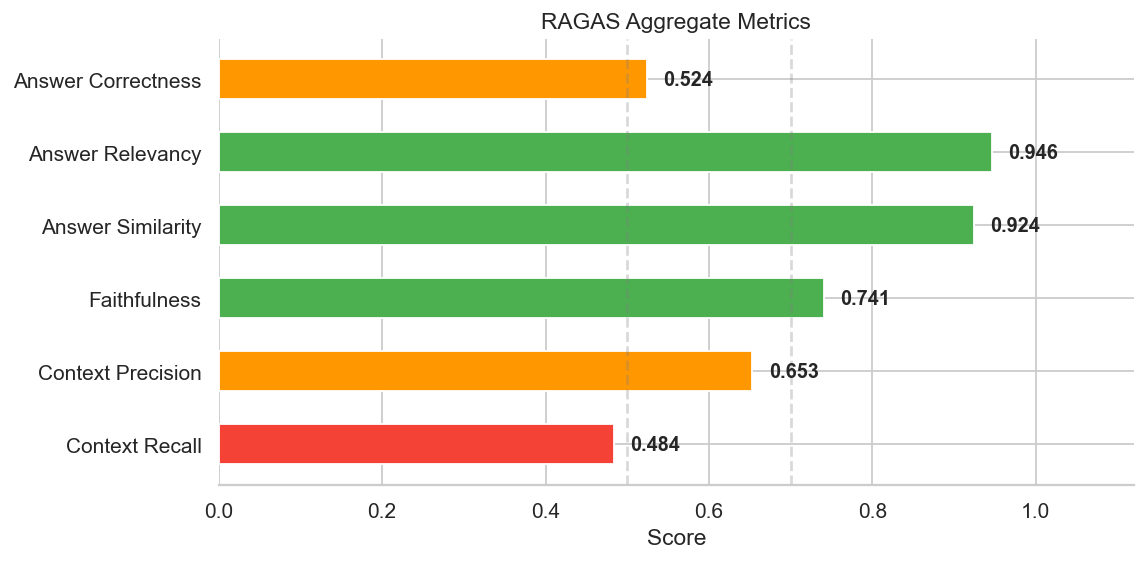

In [4]:
# ── Horizontal bar chart ──────────────────────────────────────────────────
means = [df[m].mean() for m in METRICS]
colors = ["#4CAF50" if v >= 0.7 else "#FF9800" if v >= 0.5 else "#F44336"
          for v in means]

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(METRIC_LABELS[::-1], means[::-1],
               color=colors[::-1], edgecolor="white", height=0.55)
for bar, val in zip(bars, means[::-1]):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=11, fontweight="bold")

ax.set_xlim(0, 1.12)
ax.axvline(0.5, color="grey", ls="--", alpha=.3)
ax.axvline(0.7, color="grey", ls="--", alpha=.3)
ax.set(xlabel="Score", title="RAGAS Aggregate Metrics")
sns.despine(left=True)
plt.tight_layout()
plt.savefig(OUT / "ragas_aggregate_bar.png", dpi=150, bbox_inches="tight")
plt.show()

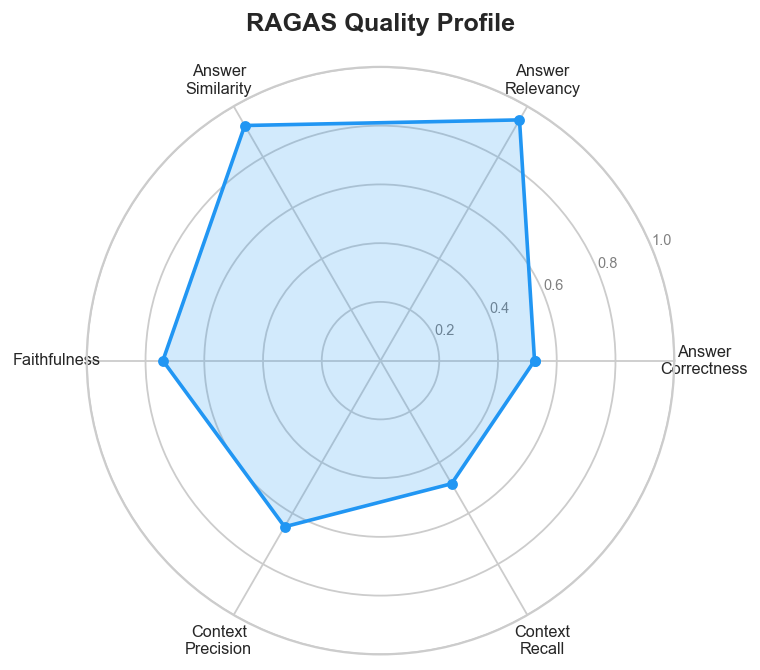

In [5]:
# ── Radar chart ───────────────────────────────────────────────────────────
labels = [l.replace(" ", "\n") for l in METRIC_LABELS]
values = means + means[:1]
angles = np.linspace(0, 2 * np.pi, len(METRICS), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.fill(angles, values, color="#2196F3", alpha=0.2)
ax.plot(angles, values, color="#2196F3", lw=2, marker="o", ms=5)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=8, color="grey")
ax.set_title("RAGAS Quality Profile", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig(OUT / "ragas_radar.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 2 &ensp; Score Distributions

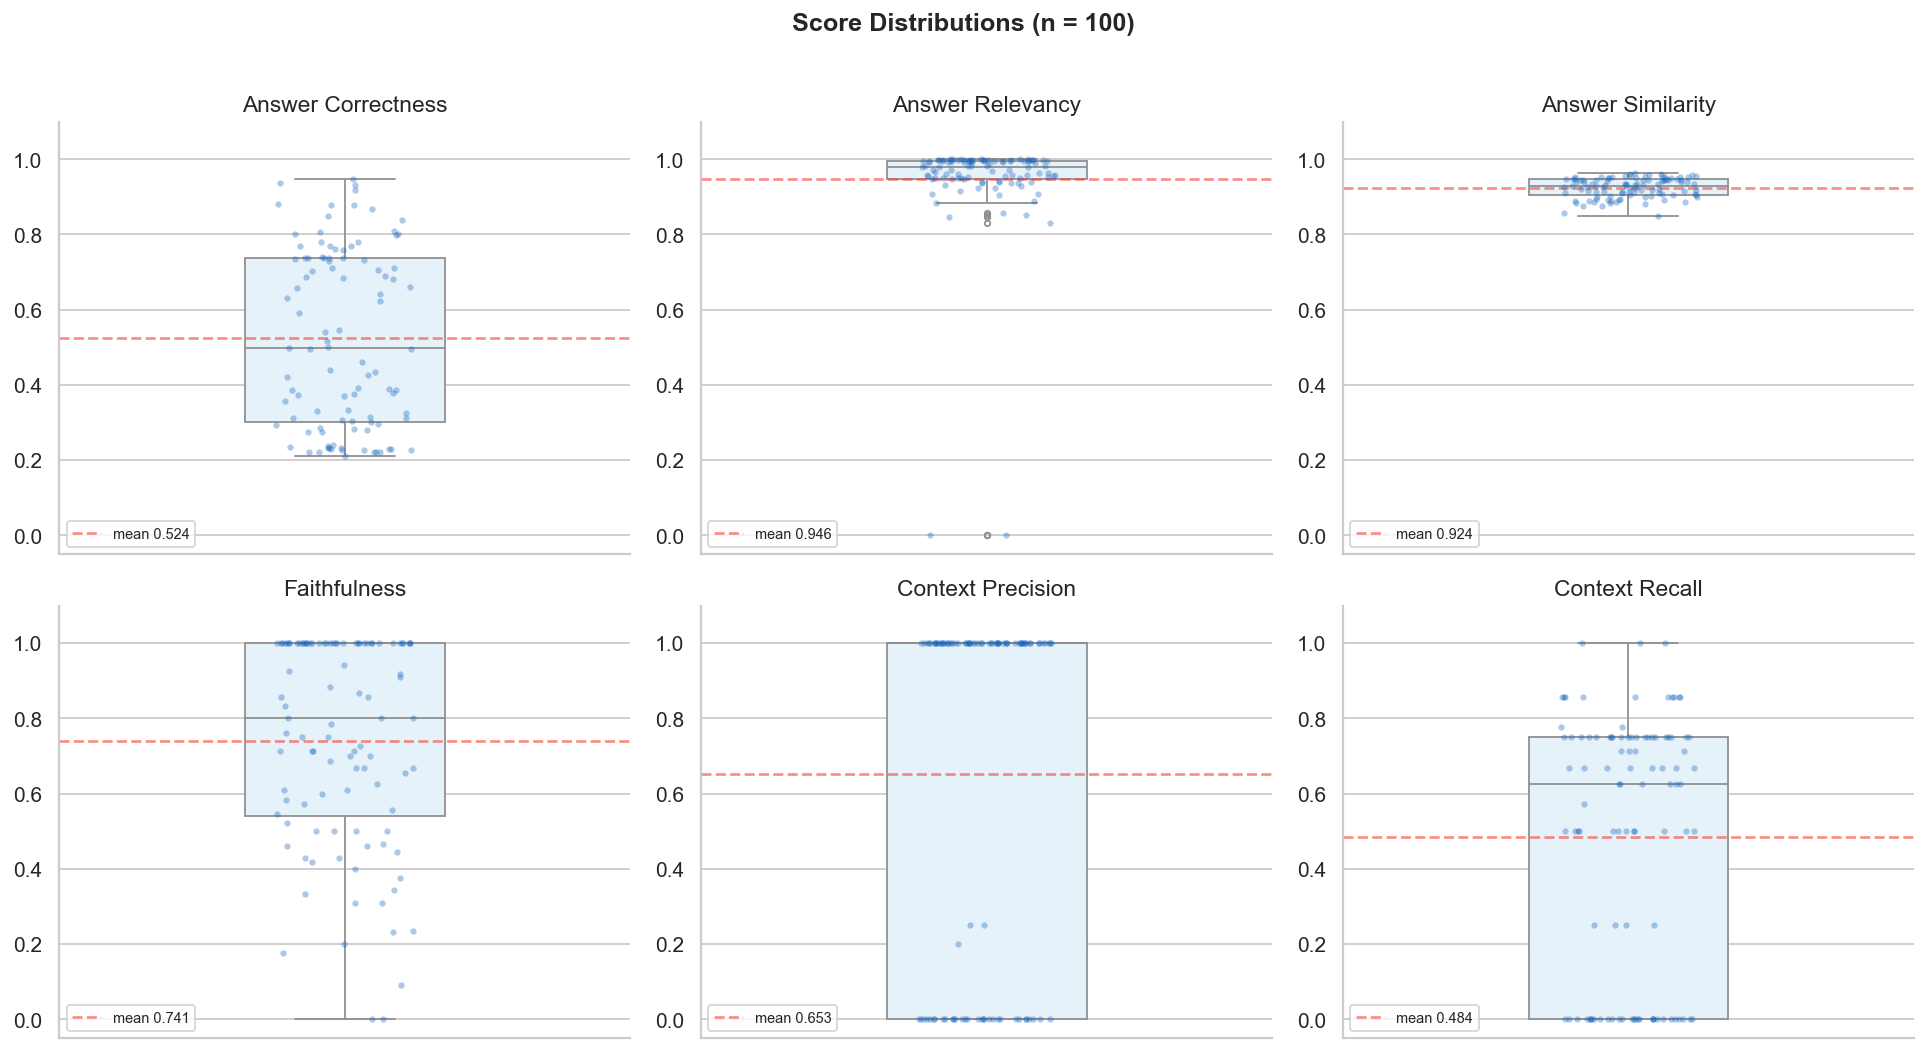

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for idx, (metric, label) in enumerate(zip(METRICS, METRIC_LABELS)):
    ax = axes[idx // 3][idx % 3]
    vals = df[metric].dropna()
    sns.boxplot(y=vals, ax=ax, color="#E3F2FD", width=0.35,
                flierprops=dict(marker="o", ms=3))
    sns.stripplot(y=vals, ax=ax, color="#1565C0", alpha=0.35, size=3.5, jitter=0.12)
    ax.axhline(vals.mean(), color="#F44336", ls="--", alpha=.6,
               label=f"mean {vals.mean():.3f}")
    ax.set(title=label, ylabel="", ylim=(-0.05, 1.1))
    ax.legend(fontsize=8, loc="lower left")

plt.suptitle("Score Distributions (n = 100)", fontsize=14, fontweight="bold", y=1.01)
sns.despine()
plt.tight_layout()
plt.savefig(OUT / "ragas_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 3 &ensp; Scores by Question Subtype

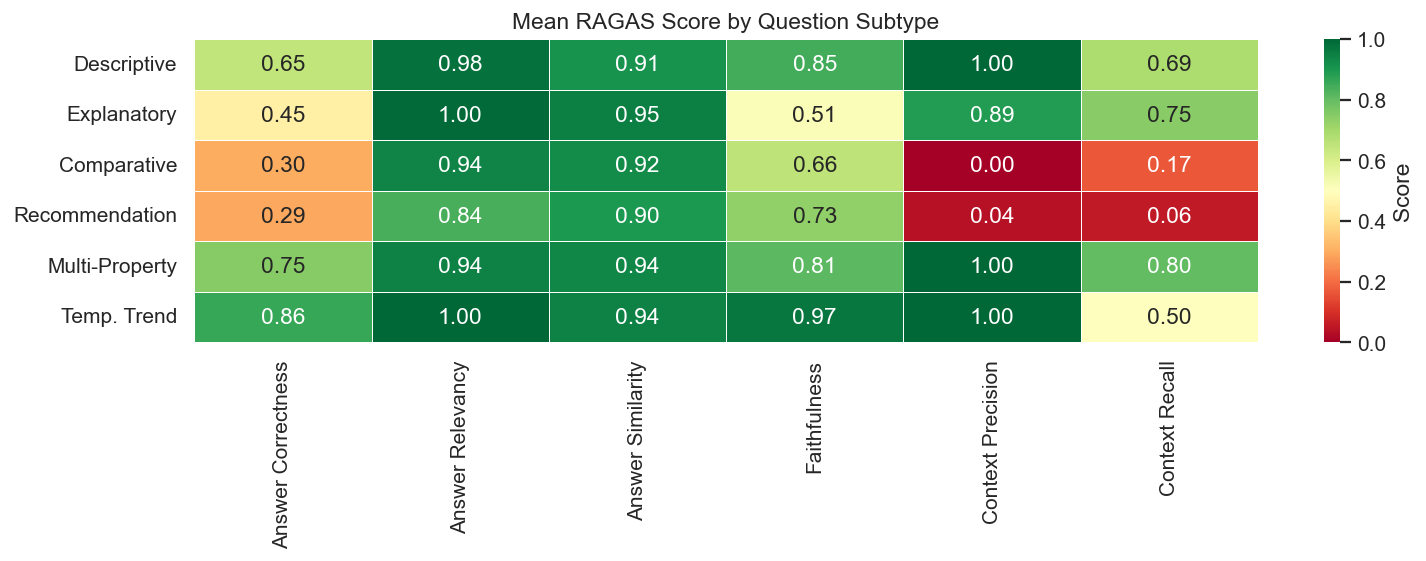

In [7]:
pivot = (df.groupby("subtype")[METRICS].mean()
           .rename(columns=METRIC_MAP)
           .reindex([s for s in SUBTYPE_ORDER if s in df["subtype"].values]))

fig, ax = plt.subplots(figsize=(12, 4.5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn",
            vmin=0, vmax=1, linewidths=.5, ax=ax,
            cbar_kws={"label": "Score"})
ax.set(title="Mean RAGAS Score by Question Subtype", ylabel="", xlabel="")
plt.tight_layout()
plt.savefig(OUT / "ragas_subtype_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# ── Per-subtype table with sample counts ──────────────────────────────────
sub_tbl = df.groupby("subtype").agg(
    n=("id", "count"),
    Correctness=("answer_correctness", "mean"),
    Relevancy=("answer_relevancy", "mean"),
    Similarity=("answer_similarity", "mean"),
    Faithfulness=("faithfulness", "mean"),
    Ctx_Precision=("llm_context_precision_with_reference", "mean"),
    Ctx_Recall=("context_recall", "mean"),
).reindex([s for s in SUBTYPE_ORDER if s in df["subtype"].values])

(sub_tbl.style
    .format("{:.3f}", subset=sub_tbl.columns[1:])
    .format("{:.0f}", subset=["n"])
    .background_gradient(cmap="RdYlGn", subset=sub_tbl.columns[1:], vmin=0, vmax=1)
    .set_caption("Table 2 — Mean scores by question subtype"))

,n,Correctness,Relevancy,Similarity,Faithfulness,Ctx_Precision,Ctx_Recall
subtype,,,,,,,
Descriptive,20,0.647,0.977,0.909,0.846,1.000,0.687
Explanatory,18,0.450,0.996,0.949,0.513,0.889,0.745
Comparative,18,0.298,0.941,0.922,0.656,0.000,0.167
Recommendation,18,0.290,0.837,0.897,0.732,0.039,0.056
Multi-Property,14,0.750,0.943,0.937,0.810,1.000,0.803
Temp. Trend,12,0.861,0.997,0.941,0.967,1.000,0.500


---
## 4 &ensp; Metric Correlations

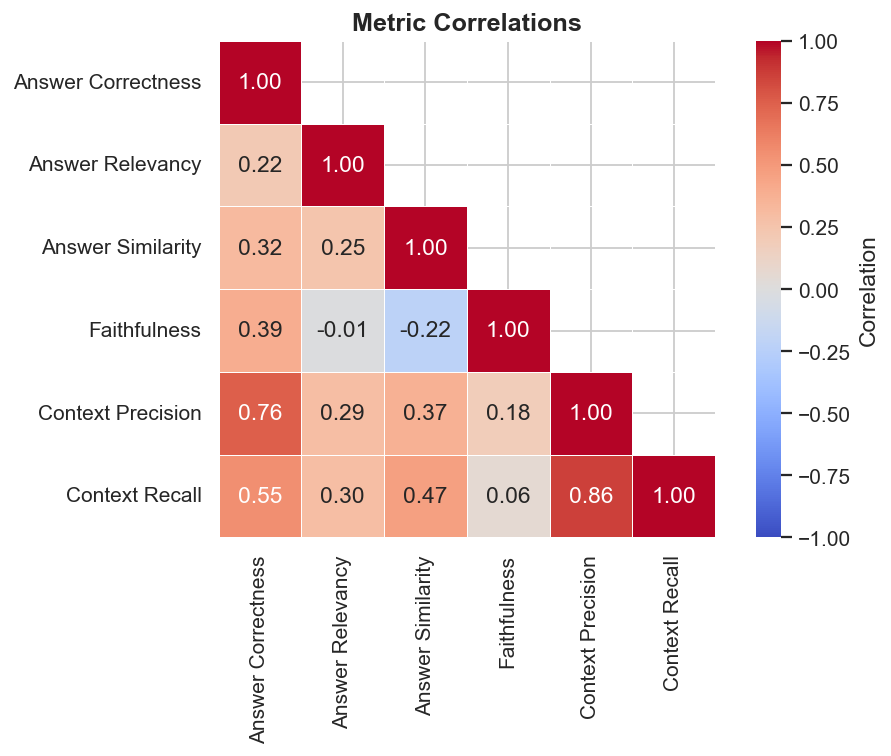

In [9]:
corr = df[METRICS].rename(columns=METRIC_MAP).corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, linewidths=.5, square=True, ax=ax,
            cbar_kws={"label": "Correlation"})
ax.set_title("Metric Correlations", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT / "ragas_correlations.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 5 &ensp; Weakest Samples

In [10]:
worst = (df.nsmallest(10, "answer_correctness")
           [["id", "subtype"] + METRICS]
           .rename(columns=METRIC_MAP)
           .reset_index(drop=True))

(worst.style
    .format("{:.2f}", subset=METRIC_LABELS)
    .background_gradient(cmap="RdYlGn", subset=METRIC_LABELS, vmin=0, vmax=1)
    .set_caption("Table 3 — 10 lowest answer-correctness samples"))

,id,subtype,Answer Correctness,Answer Relevancy,Answer Similarity,Faithfulness,Context Precision,Context Recall
0,ragas_comp_017,Comparative,0.21,0.83,0.85,0.80,nan,0.00
1,ragas_rec_018,Recommendation,0.22,0.95,0.88,0.79,0.00,0.00
2,ragas_comp_016,Comparative,0.22,0.94,0.88,0.34,nan,0.00
3,ragas_rec_009,Recommendation,0.22,0.91,0.88,0.94,0.00,0.00
4,ragas_rec_011,Recommendation,0.22,0.94,0.89,0.88,0.00,0.00
5,ragas_rec_017,Recommendation,0.22,0.95,0.89,0.76,0.00,0.00
6,ragas_rec_010,Recommendation,0.23,0.96,0.90,1.00,0.00,0.00
7,ragas_rec_013,Recommendation,0.23,0.95,0.90,0.43,0.00,0.00
8,ragas_rec_016,Recommendation,0.23,0.95,0.91,0.31,0.00,0.00
9,ragas_comp_015,Comparative,0.23,0.91,0.91,0.69,0.00,0.00


In [11]:
# ── Score distribution highlights ─────────────────────────────────────────
highlights = pd.DataFrame([
    {"Condition": "Faithfulness = 1.0",      "Count": int((df.faithfulness == 1).sum())},
    {"Condition": "Relevancy >= 0.95",        "Count": int((df.answer_relevancy >= .95).sum())},
    {"Condition": "Correctness < 0.30",       "Count": int((df.answer_correctness < .3).sum())},
    {"Condition": "Context Recall < 0.30",    "Count": int((df.context_recall < .3).sum())},
]).set_index("Condition")
highlights["Pct"] = (highlights["Count"] / len(df)).map("{:.0%}".format)

display(highlights.style.set_caption("Score distribution highlights (n = 100)"))

,Count,Pct
Condition,,
Faithfulness = 1.0,39,39%
Relevancy >= 0.95,72,72%
Correctness < 0.30,25,25%
Context Recall < 0.30,33,33%


---
## 6 &ensp; Summary

In [12]:
interp = {
    "Answer Correctness":  ("Moderate",  "Strict F1 penalises verbose but correct answers"),
    "Answer Relevancy":    ("Excellent", "Answers consistently address the question"),
    "Answer Similarity":   ("Excellent", "Semantic meaning closely matches reference"),
    "Faithfulness":        ("Good",      "Most claims grounded in retrieved context"),
    "Context Precision":   ("Moderate",  "Relevant contexts generally ranked well"),
    "Context Recall":      ("Moderate",  "Reconstructed contexts miss some KG data"),
}

summary = pd.DataFrame([
    {"Metric": label, "Score": f"{df[m].mean():.3f}",
     "Rating": interp[label][0], "Note": interp[label][1]}
    for m, label in zip(METRICS, METRIC_LABELS)
]).set_index("Metric")

display(summary.style.set_caption("Table 4 — RAGAS summary"))

print("\nKey findings:")
print("  - Highly relevant (0.95) and semantically accurate (0.92) answers")
print("  - Faithfulness at 0.74 shows strong grounding in retrieved KG data")
print("  - Answer correctness (0.52) reflects strict F1 scoring, not factual errors")
print("  - Context recall (0.48) limited by context reconstruction from training data")

,Score,Rating,Note
Metric,,,
Answer Correctness,0.524,Moderate,Strict F1 penalises verbose but correct answers
Answer Relevancy,0.946,Excellent,Answers consistently address the question
Answer Similarity,0.924,Excellent,Semantic meaning closely matches reference
Faithfulness,0.741,Good,Most claims grounded in retrieved context
Context Precision,0.653,Moderate,Relevant contexts generally ranked well
Context Recall,0.484,Moderate,Reconstructed contexts miss some KG data



Key findings:
  - Highly relevant (0.95) and semantically accurate (0.92) answers
  - Faithfulness at 0.74 shows strong grounding in retrieved KG data
  - Answer correctness (0.52) reflects strict F1 scoring, not factual errors
  - Context recall (0.48) limited by context reconstruction from training data
